Kiến trúc mạng policy
Xây dựng kiến trúc cho một Policy Network để bạn có thể dùng sau này khi huấn luyện agent theo phương pháp policy gradient.

Mạng policy nhận trạng thái làm đầu vào và xuất ra phân phối xác suất trên không gian hành động. Với môi trường Lunar Lander, bạn làm việc với bốn hành động rời rạc, nên bạn muốn mạng xuất ra một xác suất cho từng hành động đó.

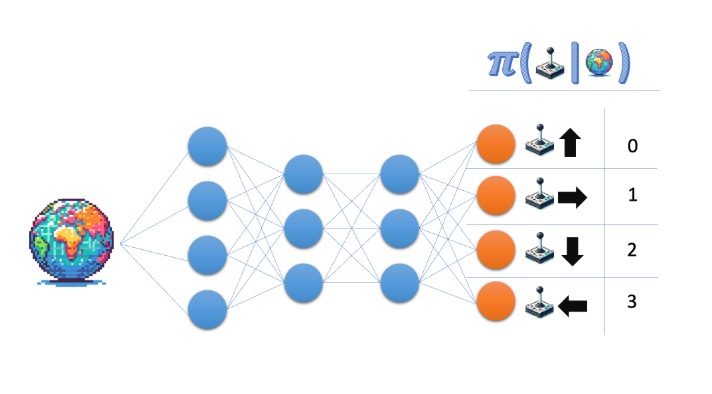

Hướng dẫn
100 XP
Chỉ định kích thước cho tầng đầu ra của mạng policy; để linh hoạt, hãy dùng tên biến thay vì con số cụ thể.
Đảm bảo tầng cuối cùng trả về các xác suất.

In [ ]:
class PolicyNetwork(nn.Module):
  def __init__(self, state_size, action_size):
    super(PolicyNetwork, self).__init__()
    
    self.fc1 = nn.Linear(state_size, 64)
    self.fc2 = nn.Linear(64, 64)
    # Give the desired size for the output layer
    self.fc3 = nn.Linear(64, ____)

  def forward(self, state):
    x = torch.relu(self.fc1(torch.tensor(state)))
    x = torch.relu(self.fc2(x))
    # Obtain the action probabilities
    action_probs = ____(self.fc3(x), dim=-1)
    return action_probs
  
policy_network = PolicyNetwork(8, 4)
action_probs = policy_network(state)
print('Action probabilities:', action_probs)

In [ ]:
"""
Gợi ý
Mạng policy cần tạo ra một xác suất cho mỗi hành động có thể.
Dùng hàm softmax trong gói torch.

class PolicyNetwork(nn.Module):
  def __init__(self, state_size, action_size):
    super(PolicyNetwork, self).__init__()
    self.fc1 = nn.Linear(state_size, 64)
    self.fc2 = nn.Linear(64, 64)
    # Give the desired size for the output layer
    self.fc3 = nn.Linear(64, action_size)

  def forward(self, state):
    x = torch.relu(self.fc1(torch.tensor(state)))
    x = torch.relu(self.fc2(x))
    # Obtain the action probabilities
    action_probs = torch.softmax(self.fc3(x), dim=-1)
    return action_probs
  
policy_network = PolicyNetwork(8, 4)
action_probs = policy_network(state)
print('Action probabilities:', action_probs)


"""

Làm việc với phân phối rời rạc
Bạn sắp làm việc với các policy ngẫu nhiên: policy mô tả hành vi của agent ở một trạng thái nhất định dưới dạng một phân phối xác suất trên các hành động.

PyTorch có thể biểu diễn các phân phối rời rạc bằng lớp torch.distributions.Categorical, và bạn sẽ thực hành với nó ngay bây giờ.

Bạn sẽ thấy rằng thực ra các số dùng làm đầu vào không nhất thiết phải cộng lại thành 1 như xác suất; chúng sẽ được chuẩn hóa tự động.

Hướng dẫn
100 XP
Khởi tạo phân phối xác suất dạng categorical.
Lấy một mẫu từ phân phối.
Chỉ định 3 số dương có tổng bằng 1 để dùng làm xác suất.
Chỉ định 5 số dương; Categorical sẽ âm thầm chuẩn hóa chúng để thu được các xác suất.

In [1]:
from torch.distributions import Categorical

def sample_from_distribution(probs):
    print(f"\nInput: {probs}")
    probs = torch.tensor(probs, dtype=torch.float32)
    # Instantiate the categorical distribution
    dist = ____(probs)
    # Take one sample from the distribution
    sampled_index = ____
    print(f"Taking one sample: index {sampled_index}, with associated probability {dist.probs[sampled_index]:.2f}")

# Specify 3 positive numbers summing to 1
sample_from_distribution([.3, ____, ____])
# Specify 5 positive numbers that do not sum to 1
sample_from_distribution([2, ____, ____, ____, ____])

NameError: name '____' is not defined

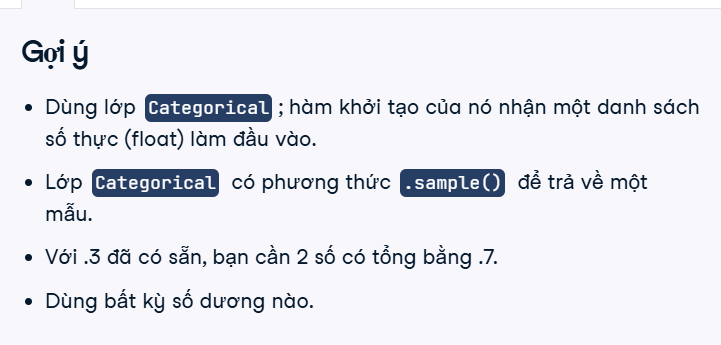

In [ ]:
"""
from torch.distributions import Categorical

def sample_from_distribution(probs):
    print(f"\nInput: {probs}")
    probs = torch.tensor(probs, dtype=torch.float32)
    # Instantiate the categorical distribution
    dist = Categorical(probs)
    # Take one sample from the distribution
    sampled_index = dist.sample()
    print(f"Taking one sample: index {sampled_index}, with associated probability {dist.probs[sampled_index]:.2f}")

# Specify 3 positive numbers summing to 1
sample_from_distribution([.3, .1, .6])
# Specify 5 positive numbers that do not sum to 1
sample_from_distribution([2, 1, 3.3, 10, 2])
"""